<a href="https://colab.research.google.com/github/DWalicki95/MaterialsVision/blob/main/notebooks/cellpose_finetuned_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

os.environ['PYTHONPATH'] = (
  '/content/MaterialsVision:' + os.environ.get('PYTHONPATH', '')
)

In [2]:
from pathlib import Path
import numpy as np
import time

from cellpose.metrics import (
    mask_ious, boundary_scores, aggregated_jaccard_index, average_precision
)
import torch
from skimage.segmentation import relabel_sequential
import gc
import pandas as pd
from typing import Dict, List
import json
import matplotlib.pyplot as plt

from datetime import datetime

from PIL import Image

In [3]:
from torch.cuda import is_available

In [4]:
import torch
print("torch:", torch.__version__)
print("cuda build:", torch.version.cuda)
print("is_available:", torch.cuda.is_available())
print("arch list:", torch.cuda.get_arch_list())

torch: 2.11.0+cu128
cuda build: 12.8
is_available: True
arch list: ['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [5]:
import shutil
from pathlib import Path

def prepare_stardist_dataset(src_dir, dst_dir):
    src_dir, dst_dir = Path(src_dir), Path(dst_dir)
    
    # Wyczyść jeśli istnieje
    if dst_dir.exists():
        shutil.rmtree(dst_dir)
    
    (dst_dir/'images').mkdir(parents=True, exist_ok=True)
    (dst_dir/'masks').mkdir(parents=True, exist_ok=True)

    for img in sorted(src_dir.glob('*_image.jpg')):
        new_name = img.stem.replace('_image', '') + img.suffix
        shutil.copy(img, dst_dir/'images'/new_name)

    for msk in sorted(src_dir.glob('*_masks.tif')):
        new_name = msk.stem.replace('_masks', '') + msk.suffix
        shutil.copy(msk, dst_dir/'masks'/new_name)

    X = sorted((dst_dir/'images').glob('*.jpg'))
    Y = sorted((dst_dir/'masks').glob('*.tif'))

    print(f"Znaleziono: {len(X)} obrazów | {len(Y)} masek")  # debug

    assert len(X) == len(Y), f"Różna liczba obrazów i masek w {dst_dir}!"
    assert all(Path(x).stem == Path(y).stem for x, y in zip(X, Y)), "Niedopasowane pary!"
    
    print(f"{dst_dir.name}: {len(X)} par — OK ✓")
    return X, Y

In [6]:
dataset_raw_path = Path('/home/dwalicki/dane/dane_treningowe/AS_GRUPA1')

In [7]:
X_test, Y_test = prepare_stardist_dataset(src_dir=dataset_raw_path, dst_dir='stardist-test-data')

Znaleziono: 0 obrazów | 0 masek
stardist-test-data: 0 par — OK ✓


# Model evaluation

In [79]:
def get_bbox_from_mask(mask: np.ndarray, relabel_image: bool = True) -> dict:
  if relabel_image:
    mask, forward, inverse_map = relabel_sequential(mask, offset=1)
  labels = np.unique(mask)
  bboxes = {}
  for label in labels[labels>0]:
    rows, cols = np.where(mask==label)
    if rows.size == 0:
      continue
    y_min, y_max = rows.min(), rows.max()
    x_min, x_max = cols.min(), cols.max()
    bboxes[int(label)] = int(x_min), int(y_min), int(x_max), int(y_max)
  return bboxes

In [80]:
def get_n_pores_from_mask(mask: np.ndarray):
  labels = np.unique(mask)
  n_pores = len(labels) - (1 if 0 in labels else 0)
  return n_pores

In [81]:
def calculate_iou(bbox_true, bbox_pred, epsilon=1e-5):
  # coordinates of the intersection box
  x1 = np.max([bbox_true[0], bbox_pred[0]])
  y1 = np.max([bbox_true[1], bbox_pred[1]])
  x2 = np.min([bbox_true[2], bbox_pred[2]])
  y2 = np.min([bbox_true[3], bbox_pred[3]])

  # area of overlap
  width = (x2 - x1)
  height = (y2 - y1)

  # if there is no overlap
  if (width<0) or (height<0):
    return 0.0
  area_of_overlap = width * height
  # combined area
  area_bbox_true = (bbox_true[2] - bbox_true[0]) * (bbox_true[3] - bbox_true[1])
  area_bbox_pred = (bbox_pred[2] - bbox_pred[0]) * (bbox_pred[3] - bbox_pred[1])
  area_combined = area_bbox_true + area_bbox_pred - area_of_overlap
  # ratio of area of overlap over combined area
  iou = area_of_overlap / (area_combined + epsilon)
  return iou

In [82]:
def get_iou_matrix(bboxes_true, bboxes_pred):
  n_bboxes_true = len(bboxes_true)
  n_bboxes_pred = len(bboxes_pred)
  I = np.zeros((n_bboxes_true, n_bboxes_pred), dtype=np.float32)
  for i in range(n_bboxes_true):
    for j in range(n_bboxes_pred):
      I[i, j] = calculate_iou(bboxes_true[i], bboxes_pred[j])
  return I

In [83]:
def calculate_pores_difference(n_pores_true: int, n_pores_pred):
  return float(np.abs(n_pores_true - n_pores_pred) / n_pores_true)

In [84]:
def greedy_match_iou(iou_matrix, threshold):
  I = iou_matrix.copy()
  all_triples_list = []
  matched_true, matched_pred = set(), set()
  matches = []
  I[I < threshold] = 0.0
  N_true, N_pred = I.shape
  # get pores difference
  pores_diff = calculate_pores_difference(N_true, N_pred)

  non_zero = np.argwhere(I>0.0)
  for (i, j) in non_zero:
    all_triples_list.append((i, j, I[i, j]))

  sorted_all_triples_list = sorted(
      all_triples_list, key=lambda x: x[2], reverse=True
  )

  for triples in sorted_all_triples_list:
    if (triples[0] not in matched_true) & (triples[1] not in matched_pred):
      matched_true.add(triples[0])
      matched_pred.add(triples[1])
      matches.append((triples[0], triples[1], triples[2]))

  TP = len(matches)
  FN = N_true - len(matched_true)
  FP = N_pred - len(matched_pred)

  precision = (TP / (TP + FP) if (TP + FP) > 0 else 0.0)
  recall = (TP / (TP + FN) if (TP+FN) > 0 else 0.0)
  f1_score = (2 * (precision * recall) / (precision + recall) if
      (precision + recall) > 0 else 0.0
  )
  iou_mean = float(
      sum(score for (_, _, score) in matches) / TP if TP > 0 else 0.0
    )

  return {
      'TP': TP,
      'FP': FP,
      'FN': FN,
      'precision': precision,
      'recall': recall,
      'f1_score': f1_score,
      'iou_mean': iou_mean,
      'pores_diff': pores_diff
  }


In [85]:
def iou_scores_batch(true_masks, pred_masks, greedy_match_threshold = 0.5):
  iou_results = {}
  for idx, (true_mask, pred_mask) in enumerate(zip(true_masks, pred_masks)):
    pred_bboxes = get_bbox_from_mask(pred_mask)
    true_bboxes = get_bbox_from_mask(true_mask)
    iou_matrix = get_iou_matrix(
        list(pred_bboxes.values()), list(true_bboxes.values())
    )
    one_img_output = greedy_match_iou(iou_matrix, greedy_match_threshold)
    iou_results[idx] = one_img_output
  return iou_results

In [86]:
def boundary_scores_batched(masks_true, masks_pred, scales, batch_size=2):
    N = len(masks_true)
    M = len(scales)

    precision_all = np.zeros((M, N), dtype=float)
    recall_all    = np.zeros((M, N), dtype=float)
    fscore_all    = np.zeros((M, N), dtype=float)

    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        # part of lists (batched solution)
        sub_true = masks_true[start:end]
        sub_pred = masks_pred[start:end]
        p_sub, r_sub, f_sub = boundary_scores(sub_true, sub_pred, scales)

        precision_all[:, start:end] = p_sub
        recall_all[:, start:end]    = r_sub
        fscore_all[:, start:end]    = f_sub

        # clean memory
        gc.collect()

    return precision_all, recall_all, fscore_all


In [87]:
def summarize_evaluation_iou(iou_results):
    TP_all, FP_all, FN_all = [], [], []
    micro_metrics = ['TP', 'FP', 'FN']

    # Identify macro metrics
    macro_metrics_list = [
        metric for metric in list(iou_results.values())[0].keys()
        if metric not in micro_metrics
    ]

    # Initialize collectors for macro metrics
    macro_values = {metric: [] for metric in macro_metrics_list}

    # Collect values from all images
    for metric_dict in iou_results.values():
        for metric, value in metric_dict.items():
            if metric in macro_metrics_list:
                macro_values[metric].append(value)
            elif metric == 'TP':
                TP_all.append(value)
            elif metric == 'FP':
                FP_all.append(value)
            elif metric == 'FN':
                FN_all.append(value)

    # Calculate macro averages
    macro_metric_results = {}
    for metric, values in macro_values.items():
        macro_metric_results[f'iou_mean_{metric}'] = np.mean(values)

    # Calculate micro metrics
    TP_all_sum = np.sum(TP_all)
    FP_all_sum = np.sum(FP_all)
    FN_all_sum = np.sum(FN_all)

    precision_micro = TP_all_sum / (
        TP_all_sum + FP_all_sum) if (TP_all_sum + FP_all_sum) > 0 else 0
    recall_micro = TP_all_sum / (
        TP_all_sum + FN_all_sum) if (TP_all_sum + FN_all_sum) > 0 else 0
    f1_micro = (
        2 * precision_micro * recall_micro
    ) / (
          precision_micro + recall_micro
        ) if (precision_micro + recall_micro) > 0 else 0

    # Prepare final report
    report = pd.DataFrame.from_dict(
        macro_metric_results, orient='index', columns=['value']
    )
    report.loc['iou_precision_micro'] = precision_micro
    report.loc['iou_recall_micro'] = recall_micro
    report.loc['iou_f1_micro'] = f1_micro

    return report

In [88]:
def summarize_evaluation_boundary_score(precision_all, recall_all, fscore_all):
  bs_precision_mean = np.mean(precision_all)
  bs_recall_mean = np.mean(recall_all)
  bs_fscore_mean = np.mean(fscore_all)
  bs_metrics_dict = {
        'boundary_score_mean_precision': bs_precision_mean,
        'boundary_score_mean_recall':    bs_recall_mean,
        'boundary_score_mean_f1':        bs_fscore_mean,
  }
  report = pd.DataFrame.from_dict(
      bs_metrics_dict, orient='index', columns=['value']
  )
  return report

In [89]:
def get_today_datetime_str():
  today_datetime = datetime.now().strftime("%m/%d/%Y %H:%M:%S")
  today_datetime = today_datetime[:-3]  # skip seconds
  today_datetime = (
      today_datetime
      .replace('-', '_')
      .replace(':', '_')
      .replace('/', '_')
      .replace(' ', '__')
  )
  return today_datetime

In [90]:
def summarize_evaluation(
    output_filename: str,
    model_params: Dict,
    evaluating_duration: float,
    iou_results: Dict,
    boundary_score_precision_all: List,
    boundary_score_recall_all: List,
    boundary_score_fscore_all: List,
    evaluation_comment: str = '',
    save_raw_iou_results: bool = True,
    save_final_results: bool = True,
    output_directory_path = None,
    add_today_datetime_to_filename: bool = True
):
  report_iou = summarize_evaluation_iou(iou_results)
  report_boundary_score = summarize_evaluation_boundary_score(
      precision_all=boundary_score_precision_all,
      recall_all=boundary_score_recall_all,
      fscore_all=boundary_score_fscore_all
  )
  report_final = pd.concat([report_iou, report_boundary_score])
  report_final['comment'] = evaluation_comment
  report_final['model_params'] = [model_params] * len(report_final)
  report_final['evaluation_duration'] = evaluating_duration
  # save files
  today_datetime_str = (
      get_today_datetime_str() if add_today_datetime_to_filename else ''
  )
  if not output_directory_path:
    output_directory_path = Path(
        '/content/drive/MyDrive/evaluation_metrics'
    )
  # save raw iou
  if save_raw_iou_results:
    output_directory_path.mkdir(parents=True, exist_ok=True)
    output_filename = (
        f'raw_iou_results_{evaluation_comment}_{today_datetime_str}.json'
    )
    output_filepath = output_directory_path / output_filename
    with open(output_filepath, 'w') as f:
      json.dump(iou_results, f)
    print('Raw iou test dictionary saved.')
  # save final results
  if save_final_results:
    output_directory_path.mkdir(parents=True, exist_ok=True)
    output_filename = (
        f'evaluation_results_{today_datetime_str}.csv'
    )
    output_filepath = output_directory_path / output_filename
    report_final.to_csv(output_filepath)
    print('Final evaluation metrics report saved.')
    return report_final

In [91]:
def visualize_results(
    imgs,
    pred_masks,
    flows,
    img_idx_to_visualize: int = 0,
    save_subsample: bool = True,
    output_directory_path = None,
    add_today_datetime_to_filename: bool = True,
    evaluation_comment: str = ''
):
  if not output_directory_path:
    output_directory_path = Path(
        '/content/drive/MyDrive/evaluation_metrics/plots'
    )
  today_datetime_str = (
      get_today_datetime_str() if add_today_datetime_to_filename else ''
  )
  # save images
  if save_subsample:
    output_directory_path.mkdir(parents=True, exist_ok=True)
    num_images = 10
    for img_idx in range(num_images):
        fig = plt.figure(figsize=(20, 12))
        plot.show_segmentation(
          fig=fig,
          maski=pred_masks[img_idx],
          img=imgs[img_idx],
          flowi=flows[img_idx][0]
        )
        plt.savefig(
            f'{output_directory_path}/{evaluation_comment}_figure_{img_idx}.jpg'
        )
        plt.close(fig)
  # show_figure
  fig = plt.figure(figsize=(30, 20))
  plot.show_segmentation(
    fig=fig,
    maski=pred_masks[img_idx_to_visualize],
    img=imgs[img_idx_to_visualize],
    flowi=flows[img_idx_to_visualize][0]
  )
  plt.show()

# Evaluation

In [1]:
from pathlib import Path
DATASET_BASEDIR = Path('/home/dwalicki/dane/dane_treningowe/AS_GRUPA1/stardist-test-data')
test_images = sorted((DATASET_BASEDIR / 'images').glob("*.jpg"))
true_masks = sorted((DATASET_BASEDIR / 'masks').glob('*.tif'))

In [2]:
pred_masks_dir = DATASET_BASEDIR / 'micro_sam_pred'

In [3]:
import matplotlib.pyplot as plt

In [4]:
MODEL_BASEDIR = Path('/home/dwalicki/results/micro-sam-lora/learning_rate_1e-5/foam_sam')
MODEL_PATH = MODEL_BASEDIR / 'best.pt'

In [5]:
print(MODEL_PATH)

/home/dwalicki/results/micro-sam-lora/learning_rate_1e-5/foam_sam/best.pt


In [6]:
import sys
sys.path.insert(0, "/home/dwalicki/Projekty/MaterialsVision")   # / na początku + katalog NADRZĘDNY

import materials_vision
print(materials_vision.__file__)

import torch
ckpt = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
print(ckpt.keys())

/home/dwalicki/Projekty/MaterialsVision/materials_vision/__init__.py


/home/dwalicki/miniconda3/envs/micro_sam_env/lib/python3.13/site-packages/torch_em/util/image.py:6: FutureWarning: elf will switch to from affogato, vigra, and nifty tohttps://github.com/computational-cell-analytics/bioimage-cpp as new backed for custom functionalityimplemented in C++, e.g. mutex watershed or multicut etc. This may lead to some changes in behavior andinterface. If you rely on elf you may want to consider pinning it to a version < 0.9
  from elf.io import open_file


dict_keys(['iteration', 'epoch', 'best_epoch', 'best_metric', 'current_metric', 'model_state', 'optimizer_state', 'init', 'train_time', 'timestamp', 'decoder_state', 'scaler_state', 'scheduler_state'])


/home/dwalicki/miniconda3/envs/micro_sam_env/lib/python3.13/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [7]:
from micro_sam.instance_segmentation import get_predictor_and_decoder, InstanceSegmentationWithDecoder

/home/dwalicki/miniconda3/envs/micro_sam_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
from micro_sam.instance_segmentation import get_predictor_and_decoder
predictor, decoder = get_predictor_and_decoder(
    model_type="vit_b",
    checkpoint_path=MODEL_PATH,
    device="cuda",
    peft_kwargs={"rank": r},
)

In [14]:
segmenter = InstanceSegmentationWithDecoder(predictor, decoder)

In [15]:
from PIL import Image

In [17]:
pred_masks_dir.mkdir(parents=True, exist_ok=True)

In [26]:
import numpy as np
import tifffile

In [40]:
import time
import numpy as np
from PIL import Image
from tqdm import tqdm

print(f"Liczba obrazów do przetworzenia: {len(test_images)}")
pred_masks_dir.mkdir(parents=True, exist_ok=True)

t_start = time.time()
for img_path in tqdm(test_images, desc="Inferencja", unit="img"):
    try:
        image = np.array(Image.open(img_path).convert("RGB"))   # spójny format wejścia

        t = time.time()
        segmenter.initialize(image)
        instance_map = segmenter.generate()
        dt = time.time() - t

        out_path = pred_masks_dir / f"{img_path.stem}.tif"
        tifffile.imwrite(out_path, instance_map.astype(np.uint16))

        tqdm.write(f"{img_path.name}: {int(instance_map.max())} instancji, {dt:.1f}s -> {out_path.name}")
    except Exception as e:
        tqdm.write(f"BŁĄD przy {img_path.name}: {e}")

print(f"Gotowe. Łączny czas: {time.time() - t_start:.1f}s")

Liczba obrazów do przetworzenia: 128


Inferencja:   1%|▎                                 | 1/128 [00:00<01:06,  1.90img/s]

40d3b5e1-AS2_40_27_jpg.rf.4067beb7f3b164ec798a360fefe64f15.jpg: 65 instancji, 0.5s -> 40d3b5e1-AS2_40_27_jpg.rf.4067beb7f3b164ec798a360fefe64f15.tif


Inferencja:   2%|▌                                 | 2/128 [00:00<00:51,  2.44img/s]

4b9d40a0-AS2_40_8_jpg.rf.0d90b4cde7173f280f2dcc8f51fb952d.jpg: 51 instancji, 0.3s -> 4b9d40a0-AS2_40_8_jpg.rf.0d90b4cde7173f280f2dcc8f51fb952d.tif


...

b93f8e50-AS2_40_21_jpg.rf.666a8081ca4e853d7dfb82f76a3e8695.jpg: 51 instancji, 0.3s -> b93f8e50-AS2_40_21_jpg.rf.666a8081ca4e853d7dfb82f76a3e8695.tif


Inferencja:  99%|███████████████████████████████▊| 127/128 [00:42<00:00,  3.01img/s]

ca386a61-AS2_40_9_jpg.rf.792c59619ae71fc798a4dd6e26b20a13.jpg: 63 instancji, 0.3s -> ca386a61-AS2_40_9_jpg.rf.792c59619ae71fc798a4dd6e26b20a13.tif


Inferencja: 100%|████████████████████████████████| 128/128 [00:43<00:00,  2.97img/s]

f2a96e5a-AS2_40_2_jpg.rf.e2d5d7f535b6060298f01076c373123c.jpg: 55 instancji, 0.3s -> f2a96e5a-AS2_40_2_jpg.rf.e2d5d7f535b6060298f01076c373123c.tif
Gotowe. Łączny czas: 43.1s


In [39]:
# import time, numpy as np

# # sprawdź podstawy
# print("CUDA:", next(predictor.model.parameters()).device)   # ma być cuda:0, nie cpu
# print("Katalog:", pred_masks_dir.resolve(), "istnieje:", pred_masks_dir.exists())
# pred_masks_dir.mkdir(parents=True, exist_ok=True)

# # jeden obraz, z czasami
# img_path = test_images[0]
# image = np.array(Image.open(img_path))
# t = time.time(); segmenter.initialize(image); print("initialize:", round(time.time()-t, 1), "s")
# t = time.time(); instance_map = segmenter.generate(); print("generate:", round(time.time()-t, 1), "s")
# print("kształt:", instance_map.shape, "liczba instancji:", int(instance_map.max()))

# import tifffile
# out = pred_masks_dir / f"{img_path.stem}.tif"
# tifffile.imwrite(out, instance_map.astype(np.uint16))
# print("zapisano:", out, "rozmiar:", out.stat().st_size, "B")

In [93]:
from pathlib import Path
from tifffile import imread

test_data_path = Path('/home/dwalicki/dane/dane_treningowe/AS_GRUPA1/stardist-test-data/masks')

mask_paths = sorted(p for p in test_data_path.glob('*') if p.is_file())   # sortuj ŚCIEŻKI
print(f"Znaleziono {len(mask_paths)} masek")

Y_test = [imread(p) for p in mask_paths]

Znaleziono 128 masek


In [94]:
from pathlib import Path
from tifffile import imread


mask_paths = sorted(p for p in pred_masks_dir.glob('*') if p.is_file())   # sortuj ŚCIEŻKI
print(f"Znaleziono {len(mask_paths)} masek")

Y_pred = [imread(p) for p in mask_paths]

Znaleziono 128 masek


In [95]:
iou_results = iou_scores_batch(
    true_masks=Y_test,
    pred_masks=Y_pred,
    greedy_match_threshold=0.5
)

In [96]:
def check_mask_shapes(true_masks, pred_masks):
    """Check for shape mismatches between true and predicted masks."""
    mismatches = []

    for i, (true_mask, pred_mask) in enumerate(zip(true_masks, pred_masks)):
        if true_mask.shape != pred_mask.shape:
            mismatches.append({
                'index': i,
                'true_shape': true_mask.shape,
                'pred_shape': pred_mask.shape
            })

    if mismatches:
        print(f"Found {len(mismatches)} shape mismatches:")
        for m in mismatches[:10]:  # Show first 10
            print(f"  Index {m['index']}: true={m['true_shape']}, pred={m['pred_shape']}")
    else:
        print("✓ All masks have matching shapes!")

    return mismatches

# Check your data
mismatches = check_mask_shapes(Y_test, Y_pred)

✓ All masks have matching shapes!


In [97]:
import numpy as np

def align_mask_shapes(mask1, mask2):
    """
    Align two masks to the same shape by cropping to minimum dimensions.

    Parameters:
    -----------
    mask1, mask2 : np.ndarray
        Masks to align

    Returns:
    --------
    mask1_aligned, mask2_aligned : np.ndarray
        Masks with matching shapes
    """
    h1, w1 = mask1.shape
    h2, w2 = mask2.shape

    # Use minimum dimensions
    min_h = min(h1, h2)
    min_w = min(w1, w2)

    # Crop both masks to minimum size
    mask1_aligned = mask1[:min_h, :min_w]
    mask2_aligned = mask2[:min_h, :min_w]

    return mask1_aligned, mask2_aligned

In [98]:
bs_precision_all, bs_recall_all, bs_fscore_all = boundary_scores_batched(
    Y_test,
    Y_pred,
    scales=[0.2],
    batch_size=16

)

In [37]:
summarize_evaluation(
    output_filename='peft-sam-lora-initial',
    output_directory_path=Path('results'),
    iou_results=iou_results,
    boundary_score_precision_all=bs_precision_all,
    boundary_score_recall_all=bs_recall_all,
    boundary_score_fscore_all=bs_fscore_all,
    evaluation_comment='peft-sam-lora-initial -- AS1 only dataset',
    save_raw_iou_results=True,
    save_final_results=True,
    model_params={},
    evaluating_duration=1,
    add_today_datetime_to_filename=True
)

Raw iou test dictionary saved.
Final evaluation metrics report saved.


,value,comment,model_params,evaluation_duration
iou_mean_precision,0.832222,stardist-initial-finetuning -- AS1 only dataset,{},1
iou_mean_recall,0.737249,stardist-initial-finetuning -- AS1 only dataset,{},1
iou_mean_f1_score,0.774707,stardist-initial-finetuning -- AS1 only dataset,{},1
iou_mean_iou_mean,0.817559,stardist-initial-finetuning -- AS1 only dataset,{},1
iou_mean_pores_diff,0.141215,stardist-initial-finetuning -- AS1 only dataset,{},1
iou_precision_micro,0.841831,stardist-initial-finetuning -- AS1 only dataset,{},1
iou_recall_micro,0.751870,stardist-initial-finetuning -- AS1 only dataset,{},1
iou_f1_micro,0.794311,stardist-initial-finetuning -- AS1 only dataset,{},1
boundary_score_mean_precision,0.768810,stardist-initial-finetuning -- AS1 only dataset,{},1
boundary_score_mean_recall,0.892492,stardist-initial-finetuning -- AS1 only dataset,{},1


In [99]:
summarize_evaluation(
    output_filename='peft-sam-lora-initial',
    output_directory_path=Path('results'),
    iou_results=iou_results,
    boundary_score_precision_all=bs_precision_all,
    boundary_score_recall_all=bs_recall_all,
    boundary_score_fscore_all=bs_fscore_all,
    evaluation_comment='peft-sam-lora-initial -- AS1 only dataset',
    save_raw_iou_results=True,
    save_final_results=True,
    model_params={},
    evaluating_duration=1,
    add_today_datetime_to_filename=True
)

Raw iou test dictionary saved.
Final evaluation metrics report saved.


,value,comment,model_params,evaluation_duration
iou_mean_precision,0.822506,peft-sam-lora-initial -- AS1 only dataset,{},1
iou_mean_recall,0.796031,peft-sam-lora-initial -- AS1 only dataset,{},1
iou_mean_f1_score,0.801234,peft-sam-lora-initial -- AS1 only dataset,{},1
iou_mean_iou_mean,0.868842,peft-sam-lora-initial -- AS1 only dataset,{},1
iou_mean_pores_diff,0.137121,peft-sam-lora-initial -- AS1 only dataset,{},1
iou_precision_micro,0.814477,peft-sam-lora-initial -- AS1 only dataset,{},1
iou_recall_micro,0.795963,peft-sam-lora-initial -- AS1 only dataset,{},1
iou_f1_micro,0.805114,peft-sam-lora-initial -- AS1 only dataset,{},1
boundary_score_mean_precision,0.914022,peft-sam-lora-initial -- AS1 only dataset,{},1
boundary_score_mean_recall,0.925777,peft-sam-lora-initial -- AS1 only dataset,{},1


In [104]:
from pathlib import Path
import numpy as np
from PIL import Image

images_dir = Path('/home/dwalicki/dane/dane_treningowe/AS_GRUPA1/stardist-test-data/images')
masks_dir  = test_data_path           # .../masks
# pred_masks_dir już masz

print("images_dir istnieje:", images_dir.exists())

img_by_stem  = {p.stem: p for p in images_dir.glob('*')     if p.is_file()}
mask_by_stem = {p.stem: p for p in masks_dir.glob('*')      if p.is_file()}
pred_by_stem = {p.stem: p for p in pred_masks_dir.glob('*') if p.is_file()}

common = sorted(set(img_by_stem) & set(mask_by_stem) & set(pred_by_stem))
print(f"Wspólnych (obraz+maska+predykcja): {len(common)}")

X_test = [np.array(Image.open(img_by_stem[s]).convert("RGB")) for s in common]
Y_test = [imread(mask_by_stem[s]) for s in common]
Y_pred = [imread(pred_by_stem[s]) for s in common]
print(len(X_test), len(Y_test), len(Y_pred))   # powinny być równe

images_dir istnieje: True
Wspólnych (obraz+maska+predykcja): 128
128 128 128


Predykcja: 35 instancji | GT: 32 instancji


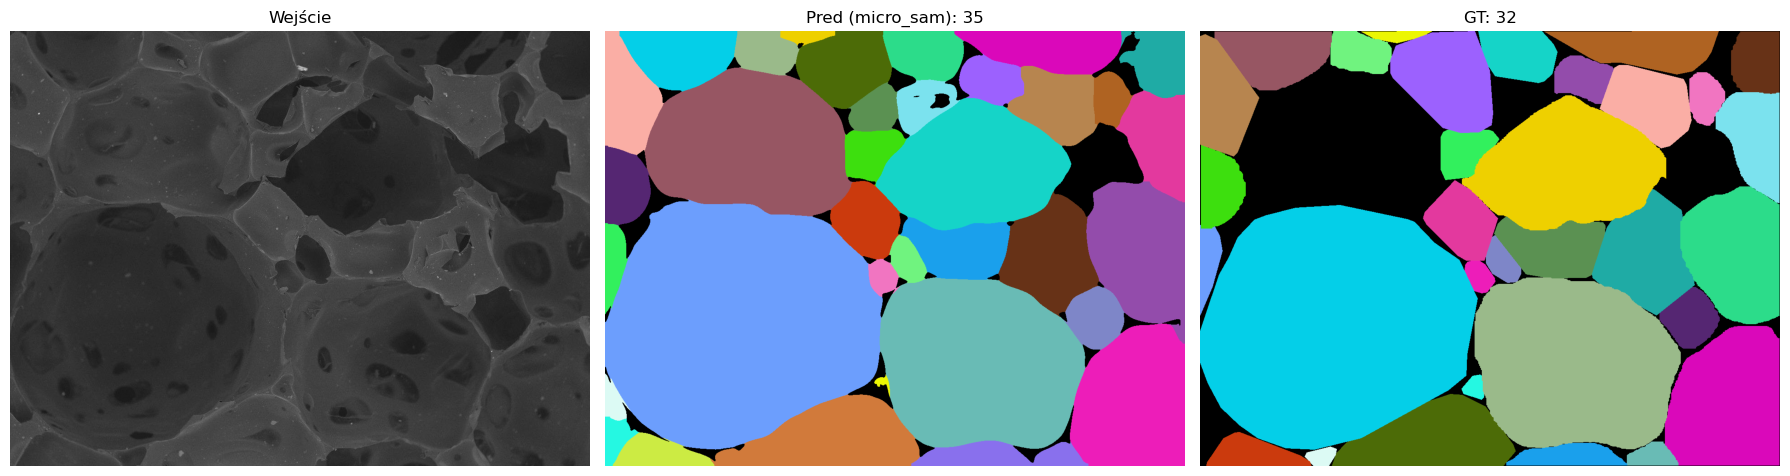

In [110]:
import numpy as np
import matplotlib.pyplot as plt

def colorize_labels(lbl, seed=0):
    """Każda instancja -> losowy kolor RGB, tło (0) na czarno."""
    rng = np.random.default_rng(seed)
    n = int(lbl.max()) + 1
    colors = rng.random((n, 3))
    colors[0] = 0
    return colors[lbl]   # zwraca obraz HxWx3

i = 4
x_input = X_test[i]
if x_input.ndim == 3:
    x_input = x_input[:, :, 0]

pred = Y_pred[i]
gt   = Y_test[i]
print(f"Predykcja: {pred.max()} instancji | GT: {gt.max()} instancji")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(x_input, cmap='gray');        axes[0].set_title('Wejście')
axes[1].imshow(colorize_labels(pred));       axes[1].set_title(f'Pred (micro_sam): {pred.max()}')
axes[2].imshow(colorize_labels(gt));         axes[2].set_title(f'GT: {gt.max()}')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()